In [19]:
import numpy as np
import matplotlib.pyplot as plt

import pandas as pd
from astropy.coordinates import SkyCoord

import healpy as hp

### Process the Neronov-Semikoz catalog

In [20]:
# load NS catalog
ns_catalog = pd.read_csv("./galcats/ns/ns_total_ovd.csv", index_col=0)

In [21]:
ns_catalog = ns_catalog[ns_catalog["z"] < 0.51]
ns_catalog.head()

,4FGL,RA,Dec,N_100,Delta_N,N_300,Gamma,z,Type,HSP,Table,ovdvalue
14,M 82,148.947,69.667,1,3,1,2.21±0.03,0.001,SBG,NaN,1,0.000000
126,Centaurus A,201.381,-43.016,5,6,1,2.574±0.019,0.002,RDG,NaN,0,0.000000
115,M 87,187.712,12.388,5,7,0,2.064±0.028,0.004,RDG,NaN,0,0.000000
28,NGC 1275,49.958,41.512,11,12,1,2.123±0.005,0.017,RDG,NaN,0,0.212933
161,H 1722+119,261.271,11.875,8,10,2,1.869±0.019,0.018,BLL,NaN,0,-0.076245


In [22]:
ns_extr = ns_catalog.query("HSP == 'E'")
ns_extr.head()

,4FGL,RA,Dec,N_100,Delta_N,N_300,Gamma,z,Type,HSP,Table,ovdvalue
157,Markarian 501,253.474,39.759,81,109,22,1.795±0.008,0.034,BLL,E,0,-0.059566
162,1ES 1727+502,262.078,50.227,5,11,4,1.785±0.022,0.055,BLL,E,0,-0.224950
169,PMN J1256-1146,194.063,-11.776,2,2,0,1.97±0.05,0.058,BLL,E,3,0.449762
68,PGC 2402248,113.362,51.880,3,5,1,1.769±0.079,0.065,BLL,E,0,0.131716
53,PKS 0548-322,87.625,-32.277,4,5,0,1.829±0.071,0.069,BLL,E,0,0.440489


In [23]:
MW_plane = SkyCoord(l=np.linspace(0, 360, 100), b=0.0, frame='galactic', unit='deg').galactic
theta_MW, phi_MW = np.pi/2 - MW_plane.b.rad, MW_plane.l.rad

EQ_plane = SkyCoord(ra=np.linspace(0, 360, 100), dec=0.0, frame='icrs', unit='deg').galactic
theta_EQ, phi_EQ = np.pi/2 - EQ_plane.b.rad, EQ_plane.l.rad

SG_plane = SkyCoord(sgl=np.linspace(0, 360, 100), sgb=0, frame='supergalactic', unit='deg').galactic
theta_SG, phi_SG = np.pi/2 - SG_plane.b.rad, SG_plane.l.rad

### Load LSS maps

In [24]:
import os
from scipy.interpolate import RegularGridInterpolator

ovd_files = os.listdir('./overdensity')
z_start, z_end = [float(f[4:7])/100 for f in ovd_files], [float(f[8:11])/100 for f in ovd_files]

zbins = z_start.copy()
zbins.append(z_end[-1])

maps_d = np.array([np.load(f"./overdensity/{f}") for f in ovd_files])
maps = np.zeros([maps_d.shape[0] + 2, maps_d.shape[1]])
maps[1:-1] = maps_d

z_data = np.zeros(len(z_start)+2)
z_data[1:-1] = 0.5 * (np.array(z_start) + np.array(z_end))
z_data[-1] = 0.5
### extend grid with zero maps @ z = 0.0 and z = 0.5

nside = hp.get_nside(maps[0])
npix = hp.get_map_size(maps[0])
pix_data = np.arange(0, npix, 1)

zp_interpolator = RegularGridInterpolator(
    (z_data, pix_data),
    maps,
    bounds_error=False,
    fill_value=0
)

In [28]:
z_grid = np.linspace(0, 0.3, 91)

zpx, pxz = np.meshgrid(z_grid, pix_data, indexing='ij')

maps_interp = zp_interpolator((zpx, pxz))

#### make a movie

/grid_mnt/vol_home/llr/astro/kleimenov/miniforge3/envs/fermipy/lib/python3.9/site-packages/healpy/visufunc.py:332: UserWarning: There are no gridspecs with layoutgrids. Possibly did not call parent GridSpec with the "figure" keyword
  pylab.draw()
/grid_mnt/vol_home/llr/astro/kleimenov/miniforge3/envs/fermipy/lib/python3.9/site-packages/healpy/visufunc.py:1567: UserWarning: There are no gridspecs with layoutgrids. Possibly did not call parent GridSpec with the "figure" keyword
  pylab.draw()
/tmp/ipykernel_1636046/1273338007.py:70: UserWarning: There are no gridspecs with layoutgrids. Possibly did not call parent GridSpec with the "figure" keyword
  ani.save(
/grid_mnt/vol_home/llr/astro/kleimenov/miniforge3/envs/fermipy/lib/python3.9/site-packages/IPython/core/pylabtools.py:152: UserWarning: There are no gridspecs with layoutgrids. Possibly did not call parent GridSpec with the "figure" keyword
  fig.canvas.print_figure(bytes_io, **kw)


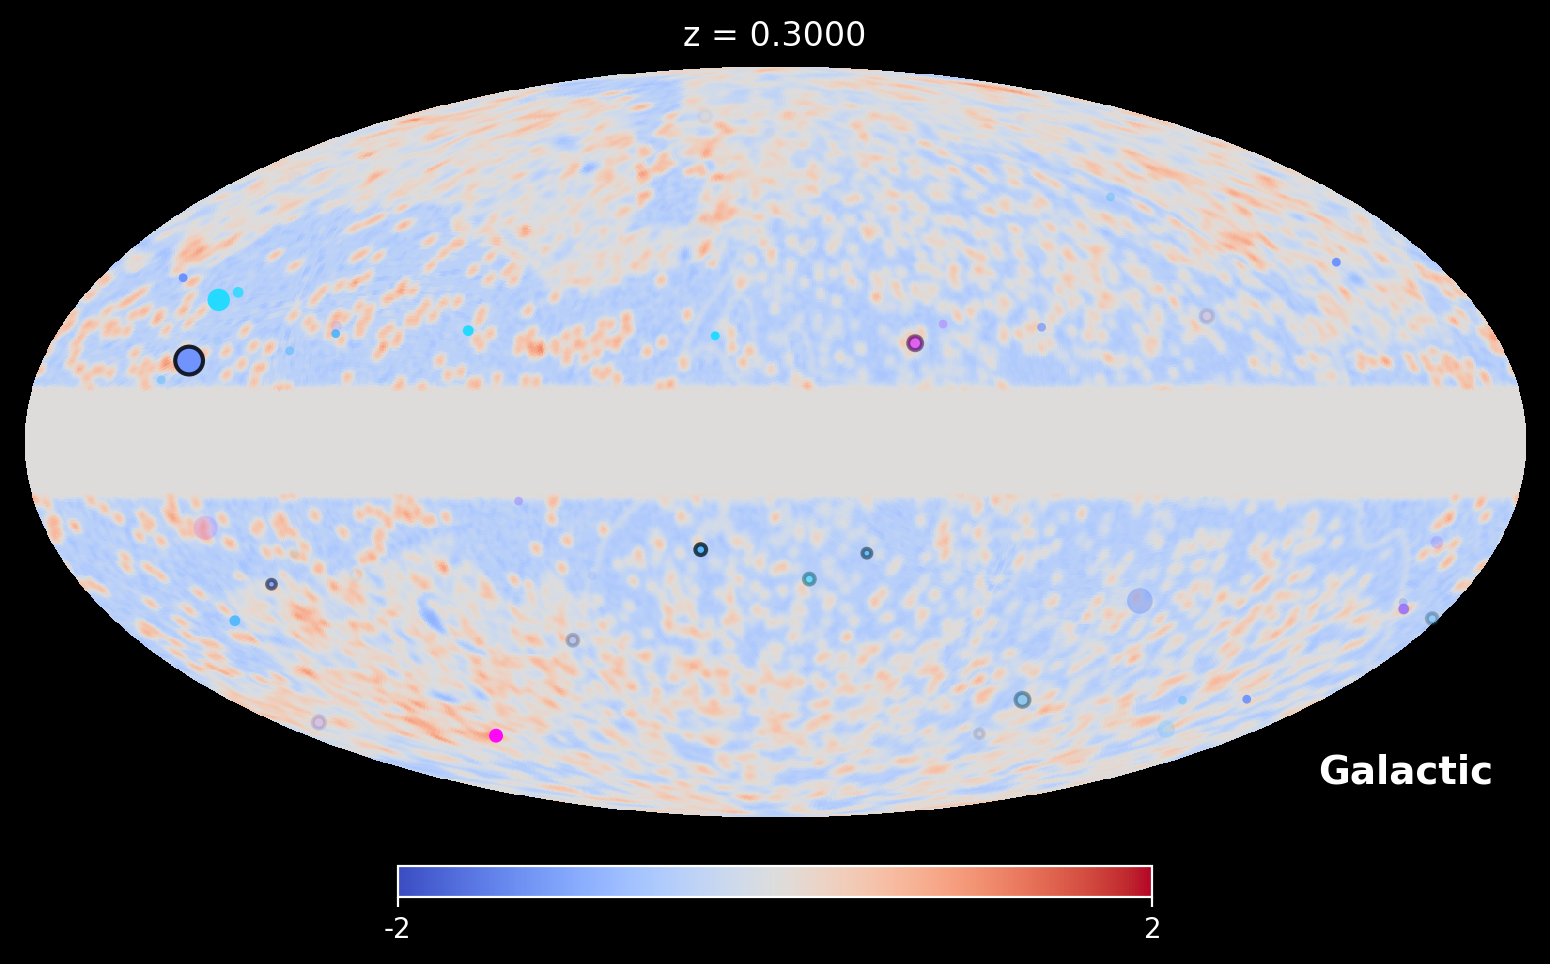

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.animation as animation
import healpy as hp

# Define background color
bg_color = '#000'
plt.style.use('dark_background')

# 1. Force the figure layout to use 0 padding at the edges using layout="constrained"
fig = plt.figure(facecolor=bg_color, layout="constrained", figsize=(10, 6), dpi=200)

psize = np.clip(5 * ns_catalog["N_100"], a_min=0.0, a_max=100.0)
psize_extr = np.clip(5 * ns_extr["N_100"], a_min=0.0, a_max=100.0)

def update(i):
    plt.clf() 
    fig.patch.set_facecolor(bg_color)
    
    # 2. Use 'margins' parameter inside mollview to remove internal padding.
    # Format is (left, bottom, right, top). 
    # Setting it to 0 or very small values (e.g., 0.01) minimizes the border.
    hp.mollview(
        maps_interp[i], 
        title=f"z = {z_grid[i]:.4f}", 
        min=-2, 
        max=2, 
        cmap='coolwarm', 
        bgcolor=bg_color,
        coord=['C', 'G'],
        hold=True,
        margins=(0.01, 0.01, 0.01, 0.01),  # <-- CRUCIAL FOR HEALPY BORDERS,
        xsize=1600,
    )
    
    # ALL BLAZARS
    cmap = plt.get_cmap("cool", lut=8)
    hp.projscatter(np.pi/2 - np.deg2rad(ns_catalog["Dec"]), 
                   np.deg2rad(ns_catalog["RA"]),
                   coord='C',
                   s=psize,
                   linewidths=(ns_catalog['HSP'] == 'E'),
                   c=ns_catalog['ovdvalue'], cmap=cmap, vmin=-0.8, vmax=0.8,
                   alpha=np.exp(-(ns_catalog["z"] - z_grid[i])**2 / 0.001))
    
    hp.projscatter(np.pi/2 - np.deg2rad(ns_extr["Dec"]), 
                       np.deg2rad(ns_extr["RA"]),
                       coord='C',
                       s=psize_extr,
                       c=ns_extr['ovdvalue'], cmap=cmap, vmin=-0.8, vmax=0.8,
                       alpha=np.exp(-(ns_extr["z"] - z_grid[i])**2 / 0.001),
                       edgecolors='black',     # <-- Force the border color to black
                       linewidths=1.5)
    
    # Force text configurations (overriding healpy defaults)
    for text in fig.gca().texts: text.set_color('white')
    for text in fig.texts: text.set_color('white')
    for ax in fig.get_axes():
        ax.set_facecolor(bg_color)
        ax.tick_params(colors='white', which='both')
        for text in ax.texts: text.set_color('white')

# Create the animation using FuncAnimation
ani = animation.FuncAnimation(
    fig, update, frames=len(z_grid), interval=100, repeat_delay=1000
)

# 3. Save the video using bbox_inches='tight' and pad_inches=0 
# to shave off any remaining external system borders.
writer = animation.FFMpegWriter(fps=5, metadata=dict(artist='Me'), bitrate=1800)
ani.save(
    "./figures/movie.mp4", 
    writer=writer, 
    savefig_kwargs={'pad_inches': 0} # <-- CRUCIAL FOR VIDEO BORDERS
)
plt.close(fig) # Close figure window cleanly to release memory

In [32]:
import matplotlib.pyplot as plt
import matplotlib.animation as animation
import healpy as hp
import numpy as np

# 1. Initialize figure with high-res canvas specs
fig = plt.figure(figsize=(10, 6), dpi=200)
bg_color = '#000000'
plt.style.use('dark_background')

def update(i):
    # CRITICAL FIX: Use plt.cla() instead of plt.clf()
    # This clears the contents of the axes without destroying the figure pipeline
    plt.clf() 
    fig.patch.set_facecolor(bg_color)
    
    # 2. Render Mollweide projection
    hp.mollview(
        maps_interp[i], 
        title="",  
        min=-2, 
        max=2, 
        cmap='coolwarm', 
        bgcolor=bg_color,
        coord=['C', 'G'],
        hold=True,
        margins=(0.01, 0.01, 0.01, 0.01),
        xsize=2500, # High projection grid resolution
    )
    
    # White Title
    plt.title(f"z = {z_grid[i]:.4f}", color='white', fontsize=14, pad=10)
    
    # --- ALL BLAZARS & EXTREME BLAZARS LAYERS ---
    cmap = plt.get_cmap("cool", lut=8)
    alpha_values = np.exp(-(ns_catalog["z"] - z_grid[i])**2 / 0.002)
    
    hp.projscatter(np.pi/2 - np.deg2rad(ns_catalog["Dec"]), 
                   np.deg2rad(ns_catalog["RA"]),
                   coord='C', s=psize, c=ns_catalog['ovdvalue'], 
                   cmap=cmap, vmin=-0.8, vmax=0.8, alpha=alpha_values,
                   edgecolors='none')
    
    extr_mask = (ns_catalog['HSP'] == 'E')
    if np.any(extr_mask):
        hp.projscatter(np.pi/2 - np.deg2rad(ns_catalog["Dec"][extr_mask]), 
                       np.deg2rad(ns_catalog["RA"][extr_mask]),
                       coord='C', s=psize[extr_mask], c=ns_catalog['ovdvalue'][extr_mask], 
                       cmap=cmap, vmin=-0.8, vmax=0.8, alpha=alpha_values[extr_mask],
                       edgecolors='black', linewidths=1.5)
    
    # Fix text elements and properties explicitly inside the active axes
    ax = plt.gca()
    ax.set_facecolor(bg_color)
    ax.tick_params(colors='white', which='both')
    
    # Keep text annotations white
    for text in ax.texts: 
        text.set_color('white')
    for img in ax.get_images():
        cb = img.colorbar
        if cb:
            cb.ax.yaxis.set_tick_params(color='white', labelcolor='white')

# Create the animation framework
ani = animation.FuncAnimation(
    fig, update, frames=len(z_grid), interval=100, repeat_delay=1000
)

# 3. Save out the comprehensive GIF
ani.save(
    "./figures/movie_hd.gif", 
    writer='pillow', 
    fps=5, 
    savefig_kwargs={'pad_inches': 0, 'facecolor': bg_color}
)
plt.close(fig) # Close figure window cleanly to release memory